# Assignment 2

This notebook runs the same pipeline as the Python scripts in this repo:
- Load MNIST and create a **stratified 60/20/20** train/val/test split.
- Train/evaluate an **FNN (MLP)** and the **Bonus CNN**.
- run small hyperparameter sweeps and summarize results.

Repo modules used:
- `data_loader.get_dataloaders`
- `models.FNN`, `models.BonusCNN`
- `trainer.train_model`, `trainer.evaluate_model`


## 1) Install / imports

In [8]:
# If needed (uncomment):
# %pip install torch torchvision scikit-learn matplotlib seaborn

import json
import os
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from data_loader import get_dataloaders
from models import FNN, BonusCNN
from trainer import train_model, evaluate_model


## 2) Configuration

In [9]:
@dataclass
class Config:
    seed: int = 42
    epochs: int = 5
    batch_size: int = 64
    lr: float = 0.01
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
print(cfg)

np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(cfg.seed)


Config(seed=42, epochs=5, batch_size=64, lr=0.01, device='cpu')


## 3) Load MNIST (60 training set,20 validation set,and 20 testing set stratified split)

In [10]:
train_loader, val_loader, test_loader = get_dataloaders(batch_size=cfg.batch_size)


Performing stratified train_test_split (60/20/20)...
Dataset split complete: 42000 Train | 14000 Val | 14000 Test


## 4) Helpers plots and single experiment

In [11]:
def plot_history_inline(history, title_prefix=""):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title_prefix)

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Val")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True)
    axes[1].legend()

    plt.show()


def plot_confusion_matrix_inline(labels, preds, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=np.arange(10),
        yticklabels=np.arange(10),
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


def run_experiment(
    name,
    model,
    train_loader,
    val_loader,
    test_loader,
    lr,
    epochs,
    device,
    plot=True,
):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=epochs,
        device=device,
    )

    test_acc, labels, preds = evaluate_model(trained_model, test_loader, device=device)
    print(f"Test accuracy: {test_acc:.4f}")

    if plot:
        plot_history_inline(history, title_prefix=name)
        plot_confusion_matrix_inline(labels, preds, title=f"Confusion Matrix - {name}")

    return test_acc


## 5) full pipeline
we run a complete set of experiments to evaluate the performance of different neural network configurations on the MNIST dataset. The experiments include a base model, learning rate analysis, batch size analysis, neuron configuration analysis, hidden layer depth analysis, and a CNN model.

Using device: cpu
Performing stratified train_test_split (60/20/20)...
Dataset split complete: 42000 Train | 14000 Val | 14000 Test

Base_Model
Training on cpu for 5 epochs...
Training complete in 0m 46s - Best val Acc: 0.9032
Test accuracy: 0.9002


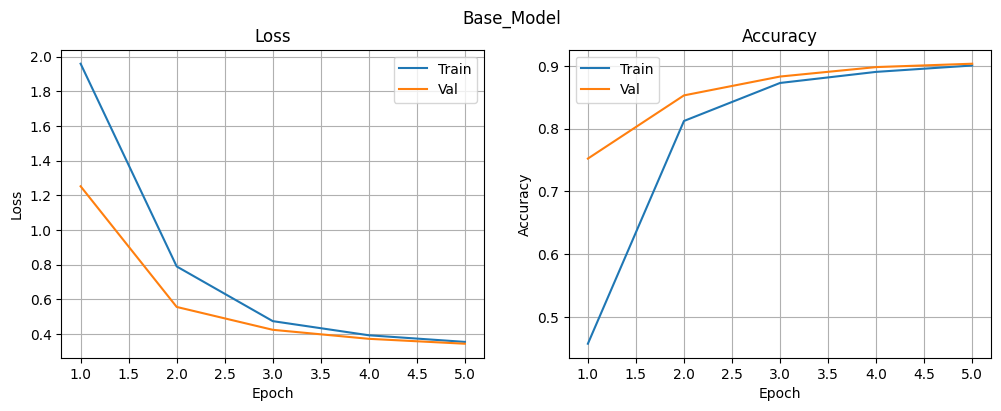

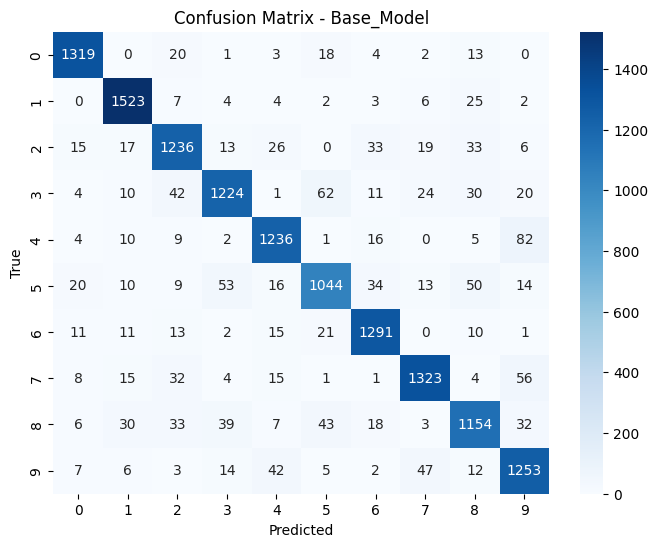


LR_0.1
Training on cpu for 5 epochs...
Training complete in 0m 48s - Best val Acc: 0.9638
Test accuracy: 0.9630

LR_0.05
Training on cpu for 5 epochs...
Training complete in 0m 54s - Best val Acc: 0.9508
Test accuracy: 0.9497

LR_0.005
Training on cpu for 5 epochs...
Training complete in 0m 51s - Best val Acc: 0.8686
Test accuracy: 0.8671

LR_0.001
Training on cpu for 5 epochs...
Training complete in 0m 56s - Best val Acc: 0.5249
Test accuracy: 0.5179
Performing stratified train_test_split (60/20/20)...
Dataset split complete: 42000 Train | 14000 Val | 14000 Test

Batch_16
Training on cpu for 5 epochs...
Training complete in 1m 7s - Best val Acc: 0.9426
Test accuracy: 0.9400
Performing stratified train_test_split (60/20/20)...
Dataset split complete: 42000 Train | 14000 Val | 14000 Test

Batch_32
Training on cpu for 5 epochs...
Training complete in 0m 55s - Best val Acc: 0.9167
Test accuracy: 0.9209
Performing stratified train_test_split (60/20/20)...
Dataset split complete: 42000 Tra

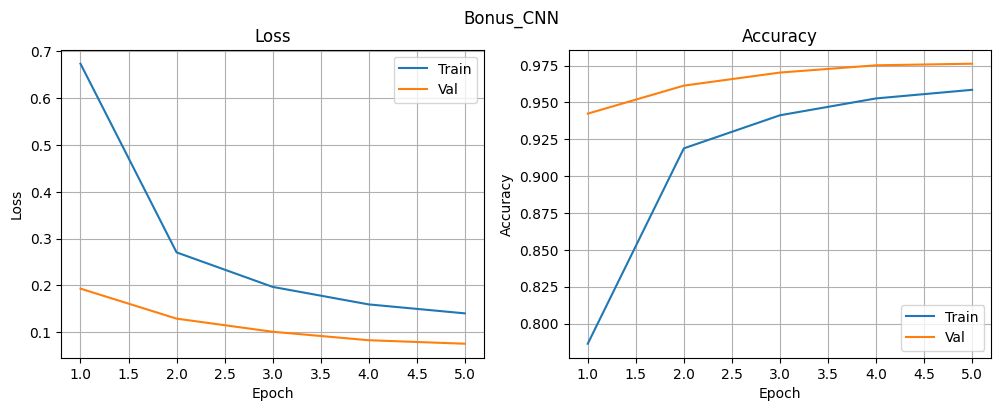

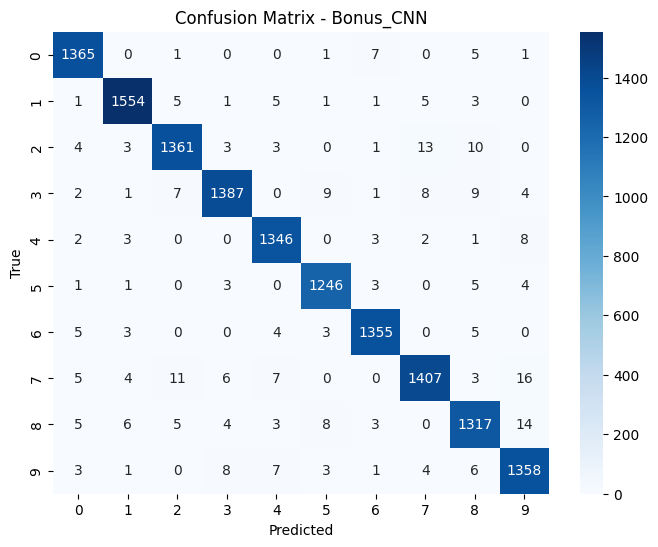



All Experiments Completed!
Base: Test Acc = 0.9002
LR_0.1: Test Acc = 0.9630
LR_0.05: Test Acc = 0.9497
LR_0.005: Test Acc = 0.8671
LR_0.001: Test Acc = 0.5179
Batch_16: Test Acc = 0.9400
Batch_32: Test Acc = 0.9209
Batch_128: Test Acc = 0.8679
Batch_256: Test Acc = 0.7611
Neurons_Config_1_H1_64_H2_32: Test Acc = 0.8976
Neurons_Config_2_H1_256_H2_128: Test Acc = 0.9026
Neurons_Config_3_H1_512_H2_128: Test Acc = 0.9015
Neurons_Config_4_H1_512_H2_256: Test Acc = 0.9026
3_Hidden: Test Acc = 0.8741
4_Hidden: Test Acc = 0.8247
5_Hidden: Test Acc = 0.2030
6_Hidden: Test Acc = 0.1126
Bonus_CNN: Test Acc = 0.9783


{'Base': 0.9002143144607544,
 'LR_0.1': 0.9629999995231628,
 'LR_0.05': 0.9497143030166626,
 'LR_0.005': 0.8671428561210632,
 'LR_0.001': 0.5178571343421936,
 'Batch_16': 0.9399999976158142,
 'Batch_32': 0.9208571314811707,
 'Batch_128': 0.8679285645484924,
 'Batch_256': 0.7610714435577393,
 'Neurons_Config_1_H1_64_H2_32': 0.8975714445114136,
 'Neurons_Config_2_H1_256_H2_128': 0.9026428461074829,
 'Neurons_Config_3_H1_512_H2_128': 0.9014999866485596,
 'Neurons_Config_4_H1_512_H2_256': 0.902571439743042,
 '3_Hidden': 0.8740714192390442,
 '4_Hidden': 0.8247143030166626,
 '5_Hidden': 0.2029999941587448,
 '6_Hidden': 0.11257142573595047,
 'Bonus_CNN': 0.9782857298851013}

In [12]:
device = torch.device(cfg.device)
print("Using device:", device)

# Set to True if you want plots for every single run (can be very slow/noisy)
PLOT_ALL = False

epochs = cfg.epochs

# Base (batch_size=cfg.batch_size)
train_loader, val_loader, test_loader = get_dataloaders(batch_size=cfg.batch_size)

results = {}

# 1) Base Model
results["Base"] = run_experiment(
    name="Base_Model",
    model=FNN([784, 128, 64, 10]),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    lr=cfg.lr,
    epochs=epochs,
    device=device,
    plot=True,
)

# 2) Learning Rate Analysis
lrs_to_test = [0.1, 0.05, 0.005, 0.001]
for lr in lrs_to_test:
    results[f"LR_{lr}"] = run_experiment(
        name=f"LR_{lr}",
        model=FNN([784, 128, 64, 10]),
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        lr=lr,
        epochs=epochs,
        device=device,
        plot=PLOT_ALL,
    )

# 3) Batch Size Analysis
batch_sizes = [16, 32, 128, 256]
for b_size in batch_sizes:
    t_loader, v_loader, ts_loader = get_dataloaders(batch_size=b_size)
    results[f"Batch_{b_size}"] = run_experiment(
        name=f"Batch_{b_size}",
        model=FNN([784, 128, 64, 10]),
        train_loader=t_loader,
        val_loader=v_loader,
        test_loader=ts_loader,
        lr=cfg.lr,
        epochs=epochs,
        device=device,
        plot=PLOT_ALL,
    )

# 4) Neurons Analysis
neuron_configs = [
    [784, 64, 32, 10],
    [784, 256, 128, 10],
    [784, 512, 128, 10],
    [784, 512, 256, 10],
]
for i, config in enumerate(neuron_configs):
    config_name = f"Neurons_Config_{i+1}_H1_{config[1]}_H2_{config[2]}"
    results[config_name] = run_experiment(
        name=config_name,
        model=FNN(config),
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        lr=cfg.lr,
        epochs=epochs,
        device=device,
        plot=PLOT_ALL,
    )

# 5) Layers Analysis
layer_configs = {
    "3_Hidden": [784, 128, 64, 32, 10],
    "4_Hidden": [784, 128, 64, 32, 16, 10],
    "5_Hidden": [784, 256, 128, 64, 32, 16, 10],
    "6_Hidden": [784, 256, 128, 64, 32, 16, 16, 10],
}
for name, config in layer_configs.items():
    results[name] = run_experiment(
        name=name,
        model=FNN(config),
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        lr=cfg.lr,
        epochs=epochs,
        device=device,
        plot=PLOT_ALL,
    )

# 6) Bonus: CNN Architecture
results["Bonus_CNN"] = run_experiment(
    name="Bonus_CNN",
    model=BonusCNN(),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    lr=cfg.lr,
    epochs=epochs,
    device=device,
    plot=True,
)

print("\n\nAll Experiments Completed!")
for k, v in results.items():
    print(f"{k}: Test Acc = {v:.4f}")

with open("results_summary.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

results


## 6) View results (sorted)

In [13]:
sorted_results = dict(sorted(results.items(), key=lambda kv: kv[1], reverse=True))
sorted_results


{'Bonus_CNN': 0.9782857298851013,
 'LR_0.1': 0.9629999995231628,
 'LR_0.05': 0.9497143030166626,
 'Batch_16': 0.9399999976158142,
 'Batch_32': 0.9208571314811707,
 'Neurons_Config_2_H1_256_H2_128': 0.9026428461074829,
 'Neurons_Config_4_H1_512_H2_256': 0.902571439743042,
 'Neurons_Config_3_H1_512_H2_128': 0.9014999866485596,
 'Base': 0.9002143144607544,
 'Neurons_Config_1_H1_64_H2_32': 0.8975714445114136,
 '3_Hidden': 0.8740714192390442,
 'Batch_128': 0.8679285645484924,
 'LR_0.005': 0.8671428561210632,
 '4_Hidden': 0.8247143030166626,
 'Batch_256': 0.7610714435577393,
 'LR_0.001': 0.5178571343421936,
 '5_Hidden': 0.2029999941587448,
 '6_Hidden': 0.11257142573595047}

## 7) Reload `results_summary.json` 

In [14]:
summary_path = "results_summary.json"
with open(summary_path, "r", encoding="utf-8") as f:
    saved_results = json.load(f)

saved_results


{'Base': 0.9002143144607544,
 'LR_0.1': 0.9629999995231628,
 'LR_0.05': 0.9497143030166626,
 'LR_0.005': 0.8671428561210632,
 'LR_0.001': 0.5178571343421936,
 'Batch_16': 0.9399999976158142,
 'Batch_32': 0.9208571314811707,
 'Batch_128': 0.8679285645484924,
 'Batch_256': 0.7610714435577393,
 'Neurons_Config_1_H1_64_H2_32': 0.8975714445114136,
 'Neurons_Config_2_H1_256_H2_128': 0.9026428461074829,
 'Neurons_Config_3_H1_512_H2_128': 0.9014999866485596,
 'Neurons_Config_4_H1_512_H2_256': 0.902571439743042,
 '3_Hidden': 0.8740714192390442,
 '4_Hidden': 0.8247143030166626,
 '5_Hidden': 0.2029999941587448,
 '6_Hidden': 0.11257142573595047,
 'Bonus_CNN': 0.9782857298851013}

## 8) Analysis
The CNN is generally expected to achieve better performance than the FNN because it preserves
the spatial structure of the MNIST images and can learn local patterns such as edges, curves,
and digit shapes. Adding dropout is also expected to reduce overfitting by narrowing the gap
between training and validation performance, while layer normalization typically stabilizes
training and produces smoother loss curves. However, in our project, this expected
improvement was not clearly observed, as the CNN did not outperform the FNN. This could be
due to several factors, including the use of a CPU instead of a GPU, which limits training time
and may prevent the model from fully converging, as well as the chosen hyperparameters or the
relatively small number of training epochs. Therefore, although CNNs with dropout and
normalization are theoretically more powerful, their advantages were not fully reflected in our
experimental results.The experimental results confirm that the CNN model achieved higher
accuracy (97.7%) compared to the FNN (around 90%), demonstrating the advantage of
convolutional architectures in capturing spatial features of images.The learning curves show
whether the model is converging properly, while the confusion matrix helps identify which digit
classes are commonly misclassified. The learning-rate sweep also shows that the choice of
learning rate has a strong effect on convergence and final test accuracy
